/tmp/ipykernel_351063/2375381296.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10, ncol=2, loc="upper right", frameon=False)


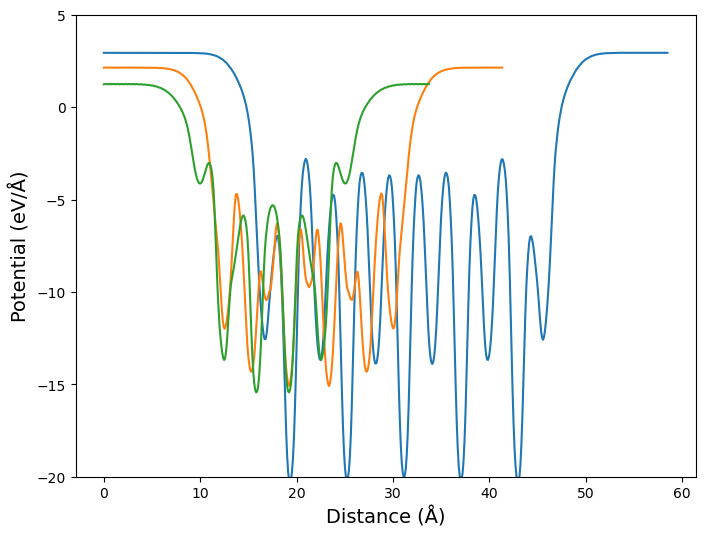

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Lê o arquivo ignorando linhas iniciadas com '#'
data001 = np.loadtxt("PLANAR_AVERAGE_001.dat", comments="#")

# Separa em dois arrays
distance001 = data001[:, 0]
potential001 = data001[:, 1]

# Lê o arquivo ignorando linhas iniciadas com '#'
data011 = np.loadtxt("PLANAR_AVERAGE_011.dat", comments="#")

# Separa em dois arrays
distance011 = data011[:, 0]
potential011 = data011[:, 1]

# Lê o arquivo ignorando linhas iniciadas com '#'
data111 = np.loadtxt("PLANAR_AVERAGE_111.dat", comments="#")

# Separa em dois arrays
distance111 = data111[:, 0]
potential111 = data111[:, 1]


# === 5. Plotar DOS parcial com suavização, filtrando os orbitais ===
plt.figure(figsize=(8, 6))

plt.plot(distance001, potential001)
plt.plot(distance011, potential011)
plt.plot(distance111, potential111)

plt.xlabel("Distance (Å)", fontsize=14)
plt.ylabel("Potential (eV/Å)", fontsize=14)
#plt.xlim(-5, 3)
plt.ylim(-20, 5)
plt.legend(fontsize=10, ncol=2, loc="upper right", frameon=False)
#plt.savefig('Cs2PbI4_dip.png', dpi = 600, bbox_inches="tight")
plt.show()

In [17]:
from pymatgen.core import Structure
import numpy as np

def expand_cell_z(poscar_in="POSCAR", poscar_out="POSCAR_expanded", factor=1.2):
    """
    Lê um POSCAR e aumenta o comprimento do vetor c por um fator escolhido.

    Parameters
    ----------
    poscar_in : str
        Caminho do POSCAR original.
    poscar_out : str
        Nome do POSCAR expandido.
    factor : float
        Fator multiplicativo para aumentar a distância (ex: 1.2 = +20%).
    """
    
    # Carrega estrutura
    structure = Structure.from_file(poscar_in)

    # Obtém matriz dos vetores de rede
    lattice = structure.lattice.matrix.copy()

    # Escala apenas o vetor c
    lattice[2] *= factor

    # Cria nova estrutura com a célula expandida
    new_struct = Structure(
        lattice,
        structure.species,
        structure.frac_coords,
        site_properties=structure.site_properties
    )

    # Salva POSCAR modificado
    new_struct.to(fmt="poscar", filename=poscar_out)
    print(f"Novo POSCAR salvo como {poscar_out} com c multiplicado por {factor}")

# Exemplo de uso:
expand_cell_z("POSCAR", "POSCAR_expanded", factor=1.3)


Novo POSCAR salvo como POSCAR_expanded com c multiplicado por 1.3
